In [1]:
import pandas as pd
from prophet import Prophet
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_pickle('electronika_clean.pkl')
df

,Order_ID,Email_new,Phone_new,Source,OrderDate,время,месяц,ChangeDate,DeliveryDate,PaymentDate,...,Quant,RowPrice,RowDiscount,RowSum,Brand,TN,TK,NomFullPath,Week,Nom_ID
2,1303000509_TT,55666668105117_iu29@yandex.ru,55485656-57565656575275,Онлайн-Резерв.,2016-03-30,08:46:30.000,201603,2016-03-30 09:31:57.000,2016-04-06 00:00:00.000,1900-01-01 00:00:00.000,...,1.0,35999.0,0.0,35999.0,Samsung,ТВ-Аудио,Телевизоры LCD,"Телевизоры, аудио, видео/Телевизоры/Smart теле...",13.0,95567.0
4,1303000510_TT,55666668105117_iu29@yandex.ru,55485656-57565656575275,Онлайн-Резерв.,2016-03-30,11:22:51.000,201603,2016-03-30 11:24:32.000,2016-04-06 00:00:00.000,1900-01-01 00:00:00.000,...,2.0,3990.0,0.0,7980.0,NaN,NaN,NaN,Установка и настройка техники/Установка и наст...,13.0,2748.0
5,1303000510_TT,55666668105117_iu29@yandex.ru,55485656-57565656575275,Онлайн-Резерв.,2016-03-30,11:22:51.000,201603,2016-03-30 11:24:32.000,2016-04-06 00:00:00.000,1900-01-01 00:00:00.000,...,2.0,4490.0,0.0,8980.0,NaN,NaN,NaN,Установка и настройка техники/Установка и наст...,13.0,7874.0
7,1303000510_TT,55666668105117_iu29@yandex.ru,55485656-57565656575275,Онлайн-Резерв.,2016-03-30,11:22:51.000,201603,2016-03-30 11:24:32.000,2016-04-06 00:00:00.000,1900-01-01 00:00:00.000,...,2.0,32999.0,0.0,65998.0,Sony,ТВ-Аудио,Телевизоры LCD,"Телевизоры, аудио, видео/Телевизоры/Smart теле...",13.0,99485.0
8,1303000510_TT,55666668105117_iu29@yandex.ru,55485656-57565656575275,Онлайн-Резерв.,2016-03-30,11:22:51.000,201603,2016-03-30 11:24:32.000,2016-04-06 00:00:00.000,1900-01-01 00:00:00.000,...,2.0,999.0,0.0,1998.0,РЭМО,Аксессуары,Аксессуары ТВ-Аудио,"Телевизоры, аудио, видео/Аксессуары для ТВ/Ант...",13.0,20709.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
357019,5898089_BX,6666449117_1u9@bk.ru,55574957-51495048515075,Онлайн-Резерв.,2016-04-30,23:51:37.000,201604,2016-05-03 12:55:07.000,2016-05-02 00:00:00.000,2016-05-02 00:10:22.000,...,1.0,899.0,0.0,899.0,Saturn,Климат,Вентиляторы бытовые,Техника для дома/Климатическая техника/Кондици...,17.0,38755.0
357021,5898095_BX,666661118109_vm27@yahoo.com,55575452-55554849505278,Онлайн-Резерв.,2016-04-30,23:54:03.000,201604,2016-05-04 19:43:40.000,2016-05-07 00:00:00.000,2016-05-04 19:43:41.000,...,1.0,1090.0,0.0,1090.0,Case Logic,Аксессуары,Аксессуары для фото/видео,Фото- и видеотехника/Аксессуары для фото и вид...,17.0,31908.0
357023,5898099_BX,3110116_nt16@pisem.net,55574948-50554849554878,Онлайн-Резерв.,2016-04-30,23:56:02.000,201604,2016-05-01 11:57:42.000,2016-05-08 00:00:00.000,1900-01-01 00:00:00.000,...,1.0,6859.0,0.0,6859.0,ELIKOR,Крупная бытовая техника,Встраиваемая техника,Встраиваемая техника/Вытяжки/,17.0,140459.0
357024,5898102_BX,55666665102117_fu13@list.ru,55575648-51484956545071,Онлайн-Резерв.,2016-04-30,23:56:38.000,201604,2016-05-06 20:18:49.000,2016-05-05 00:00:00.000,2016-05-06 20:18:50.000,...,1.0,9120.0,0.0,9120.0,FORWARD,Спорт и активный отдых,Велосипеды и аксессуары,Товары для спорта и отдыха/Велосипеды и аксесс...,17.0,295956.0


# Крупная бытовая техника

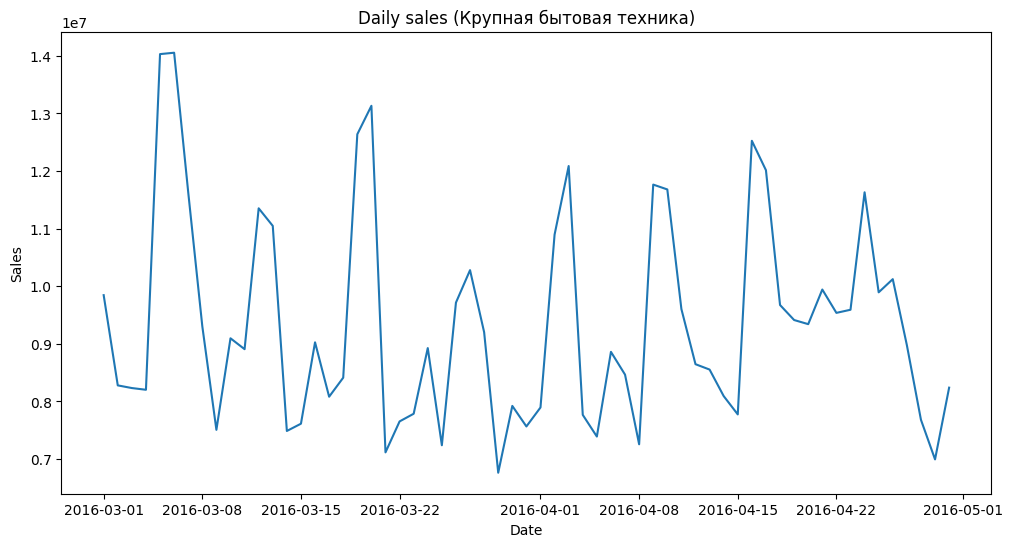

In [2]:
category_name = 'Крупная бытовая техника'
daily_sales = df[df['TN'] == f'{category_name}'][['OrderDate', 'RowSum']]\
    .groupby('OrderDate').sum()\
    .resample('D').sum()
daily_sales.reset_index(inplace=True)
daily_sales.rename(columns={'OrderDate': 'ds', 'RowSum': 'y'}, inplace=True)
daily_sales.sort_values(by='ds', inplace=True)

plt.figure(figsize=(12, 6))
sns.lineplot(data=daily_sales, x='ds', y='y')
plt.title(f"Daily sales ({category_name})")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.show()

19:29:28 - cmdstanpy - INFO - Chain [1] start processing
19:29:28 - cmdstanpy - INFO - Chain [1] done processing


,yhat,yhat_lower,yhat_upper,y
ds,,,,
2016-03-01,8.661971e+06,7.362461e+06,9.840103e+06,9842440.0
2016-03-02,8.763587e+06,7.479388e+06,1.009450e+07,8274470.0
2016-03-03,8.837645e+06,7.624710e+06,1.011458e+07,8228073.0
2016-03-04,8.439676e+06,7.133755e+06,9.732640e+06,8198159.0
2016-03-05,1.233294e+07,1.111640e+07,1.358652e+07,14031438.0
...,...,...,...,...
2016-04-26,7.399267e+06,6.176659e+06,8.567557e+06,10120519.0
2016-04-27,7.503621e+06,6.207990e+06,8.817864e+06,8974232.0
2016-04-28,7.580418e+06,6.235041e+06,8.815635e+06,7676625.0


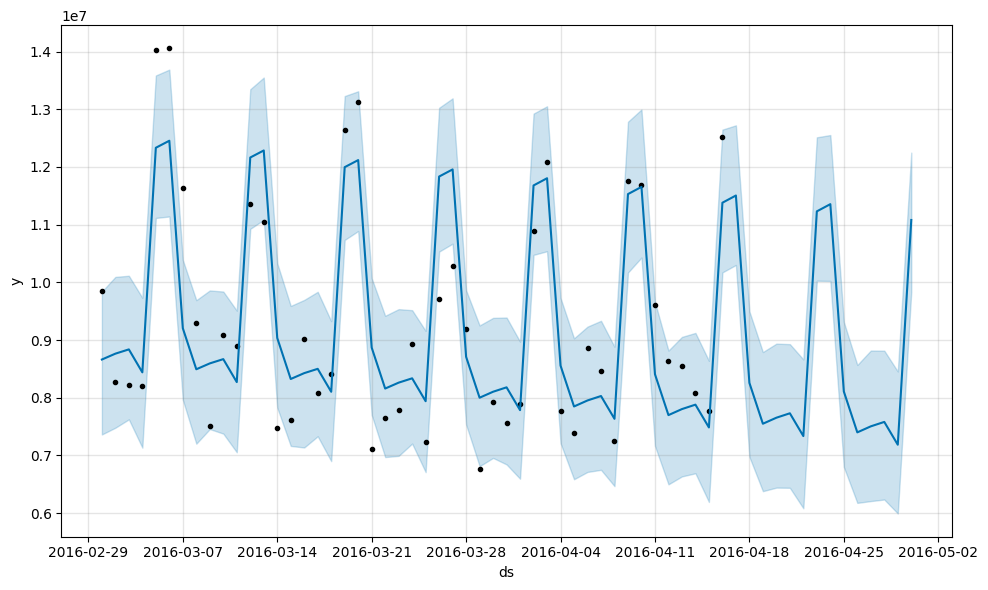

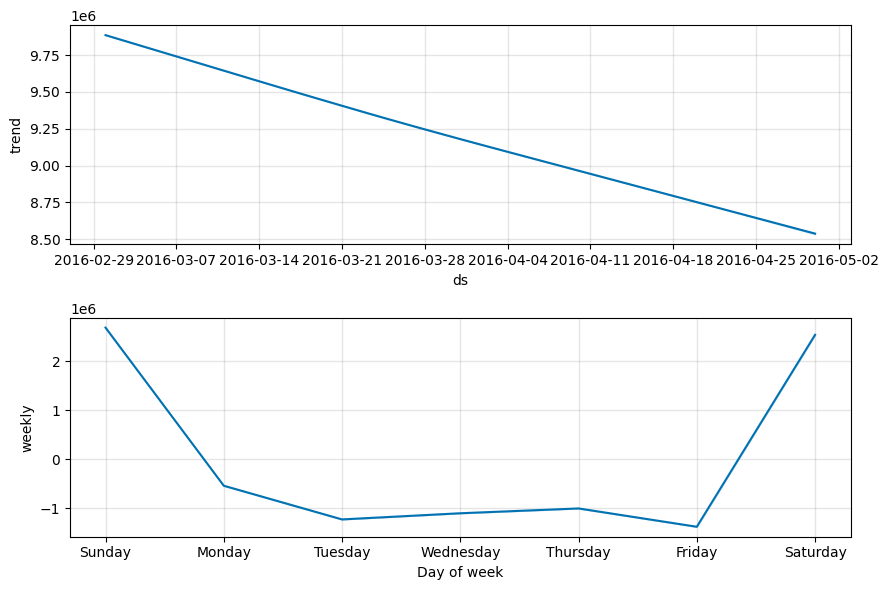

In [3]:
from sklearn.metrics import mean_absolute_percentage_error

model = Prophet()
model.fit(daily_sales[:-14])
future = model.make_future_dataframe(periods=14)
forecast = model.predict(future)
model.plot(forecast)
model.plot_components(forecast)
cmp_df = forecast.set_index('ds')[['yhat', 'yhat_lower', 'yhat_upper']].join(daily_sales.set_index('ds'))
cmp_df

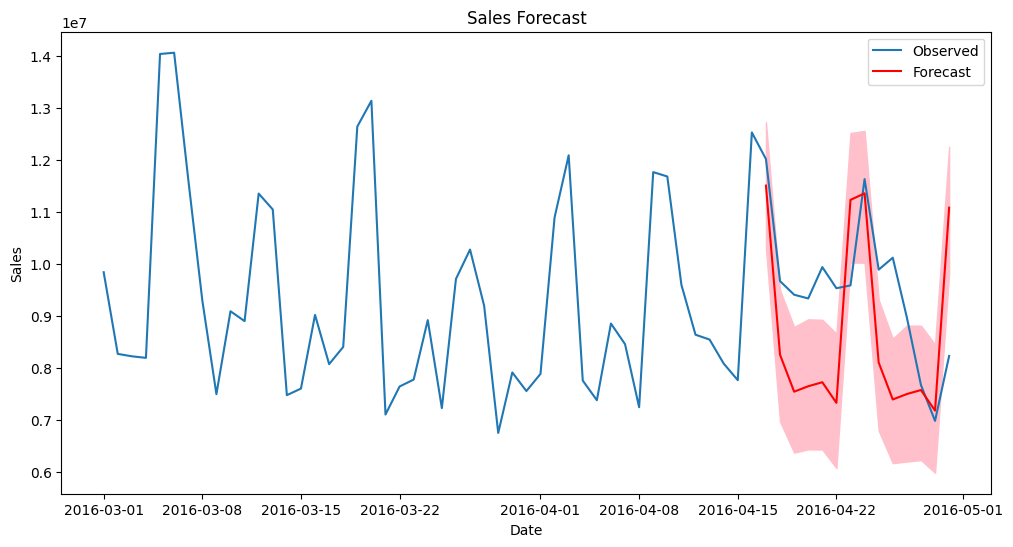

MAPE: 8.691724715109139


In [4]:
from sklearn.metrics import mean_absolute_percentage_error

# Plot the forecast
plt.figure(figsize=(12, 6))
plt.plot(cmp_df[['y']], label='Observed')
plt.plot(cmp_df[['yhat']][-14:], label='Forecast', color='red')
plt.fill_between(cmp_df[-14:].index, cmp_df['yhat_lower'][-14:], cmp_df['yhat_upper'][-14:], color='pink')
plt.title("Sales Forecast")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.show()

mape = mean_absolute_percentage_error(cmp_df['y'][:-14], cmp_df['yhat'][:-14]) * 100.0
print(f'MAPE: {mape}')

# Сделай Сам

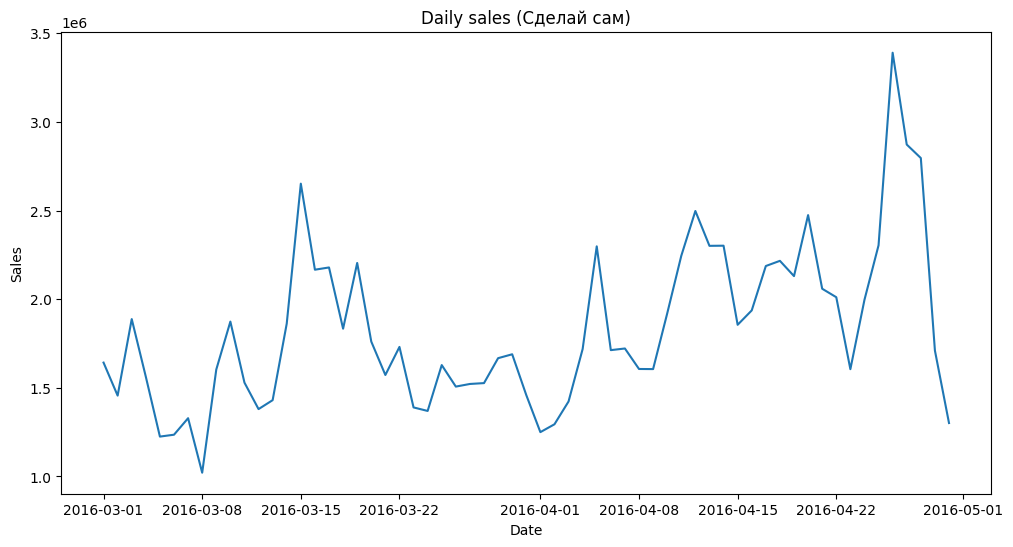

In [5]:
category_name = 'Сделай сам'
daily_sales = df[df['TN'] == f'{category_name}'][['OrderDate', 'RowSum']]\
    .groupby('OrderDate').sum()\
    .resample('D').sum()
daily_sales.reset_index(inplace=True)
daily_sales.rename(columns={'OrderDate': 'ds', 'RowSum': 'y'}, inplace=True)
daily_sales.sort_values(by='ds', inplace=True)

plt.figure(figsize=(12, 6))
sns.lineplot(data=daily_sales, x='ds', y='y')
plt.title(f"Daily sales ({category_name})")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.show()

19:29:58 - cmdstanpy - INFO - Chain [1] start processing


19:29:58 - cmdstanpy - INFO - Chain [1] done processing


,yhat,yhat_lower,yhat_upper,y
ds,,,,
2016-03-01,1.717214e+06,1.333557e+06,2.090581e+06,1642391.0
2016-03-02,1.547434e+06,1.162959e+06,1.946281e+06,1456211.0
2016-03-03,1.615158e+06,1.215162e+06,1.988429e+06,1887812.0
2016-03-04,1.397411e+06,1.017143e+06,1.775392e+06,1562647.0
2016-03-05,1.381372e+06,1.001156e+06,1.748253e+06,1225080.0
...,...,...,...,...
2016-04-26,2.283776e+06,1.889422e+06,2.679410e+06,3390182.0
2016-04-27,2.113997e+06,1.731515e+06,2.510051e+06,2872312.0
2016-04-28,2.181721e+06,1.810375e+06,2.584167e+06,2796143.0


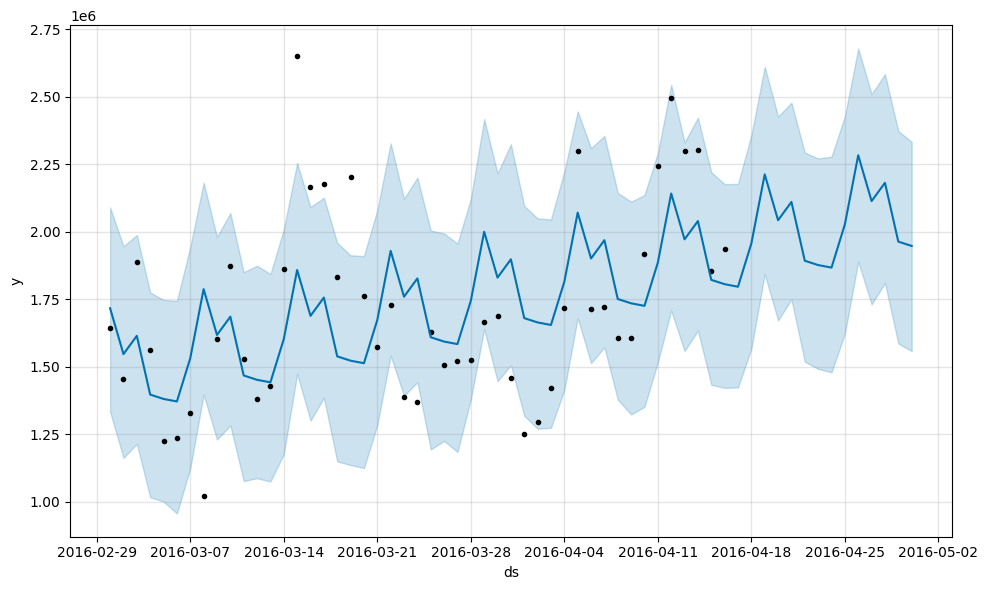

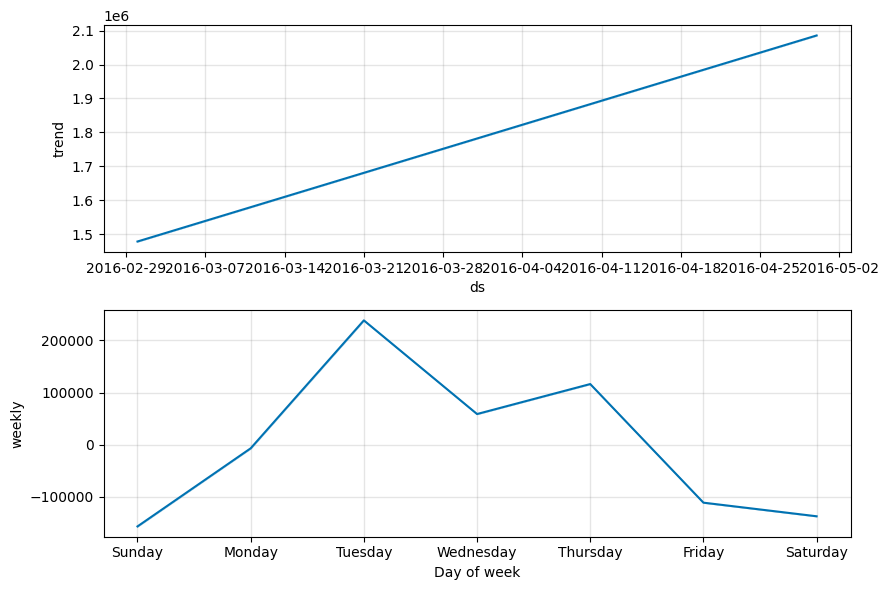

In [6]:
from sklearn.metrics import mean_absolute_percentage_error

model = Prophet()
model.fit(daily_sales[:-14])
future = model.make_future_dataframe(periods=14)
forecast = model.predict(future)
model.plot(forecast)
model.plot_components(forecast)
cmp_df = forecast.set_index('ds')[['yhat', 'yhat_lower', 'yhat_upper']].join(daily_sales.set_index('ds'))
cmp_df

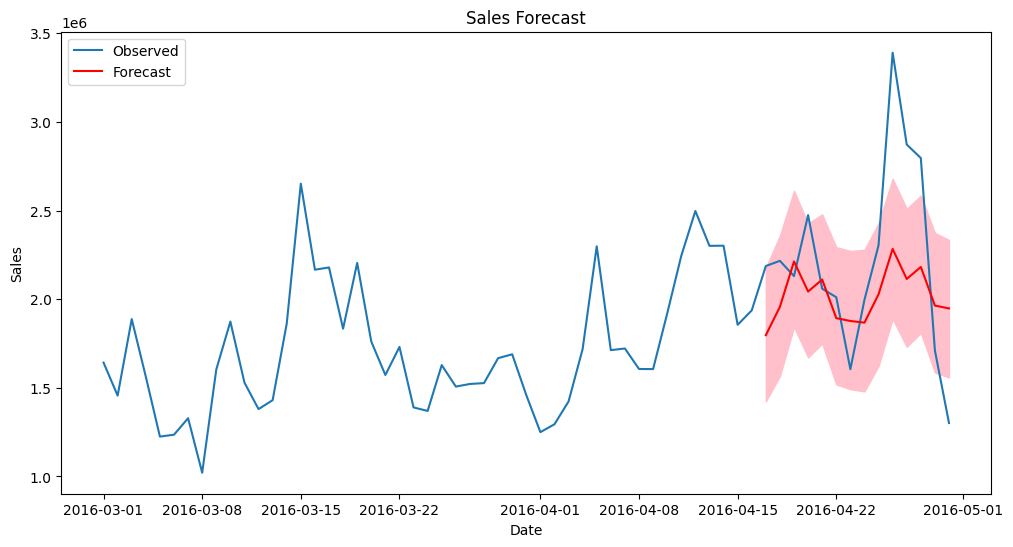

MAPE: 14.697245156058198


In [7]:
from sklearn.metrics import mean_absolute_percentage_error

# Plot the forecast
plt.figure(figsize=(12, 6))
plt.plot(cmp_df[['y']], label='Observed')
plt.plot(cmp_df[['yhat']][-14:], label='Forecast', color='red')
plt.fill_between(cmp_df[-14:].index, cmp_df['yhat_lower'][-14:], cmp_df['yhat_upper'][-14:], color='pink')
plt.title("Sales Forecast")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.show()

mape = mean_absolute_percentage_error(cmp_df['y'][:-14], cmp_df['yhat'][:-14]) * 100.0
print(f'MAPE: {mape}')

# ТВ-Аудио

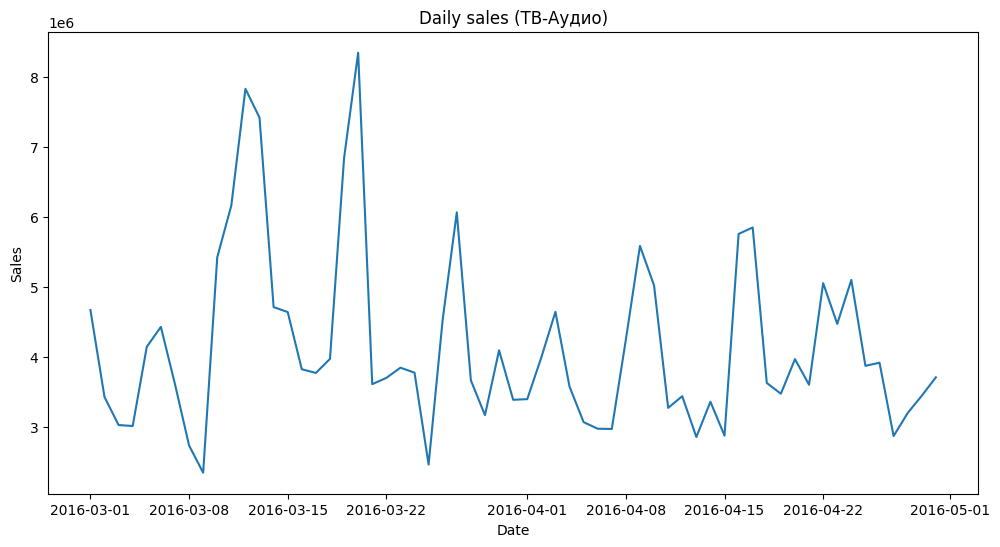

In [8]:
category_name = 'ТВ-Аудио'
daily_sales = df[df['TN'] == f'{category_name}'][['OrderDate', 'RowSum']]\
    .groupby('OrderDate').sum()\
    .resample('D').sum()
daily_sales.reset_index(inplace=True)
daily_sales.rename(columns={'OrderDate': 'ds', 'RowSum': 'y'}, inplace=True)
daily_sales.sort_values(by='ds', inplace=True)

plt.figure(figsize=(12, 6))
sns.lineplot(data=daily_sales, x='ds', y='y')
plt.title(f"Daily sales ({category_name})")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.show()

19:30:07 - cmdstanpy - INFO - Chain [1] start processing


19:30:07 - cmdstanpy - INFO - Chain [1] done processing


,yhat,yhat_lower,yhat_upper,y
ds,,,,
2016-03-01,4.020823e+06,2.780702e+06,5.230430e+06,4671151.0
2016-03-02,3.727749e+06,2.493174e+06,4.884707e+06,3430005.0
2016-03-03,4.062510e+06,2.926571e+06,5.300287e+06,3030830.0
2016-03-04,4.121993e+06,2.988932e+06,5.277237e+06,3016836.0
2016-03-05,5.912500e+06,4.695496e+06,7.083743e+06,4146939.0
...,...,...,...,...
2016-04-26,2.991229e+06,1.749901e+06,4.224978e+06,3919587.0
2016-04-27,2.698117e+06,1.528324e+06,3.840375e+06,2874065.0
2016-04-28,3.032840e+06,1.818694e+06,4.272761e+06,3202514.0


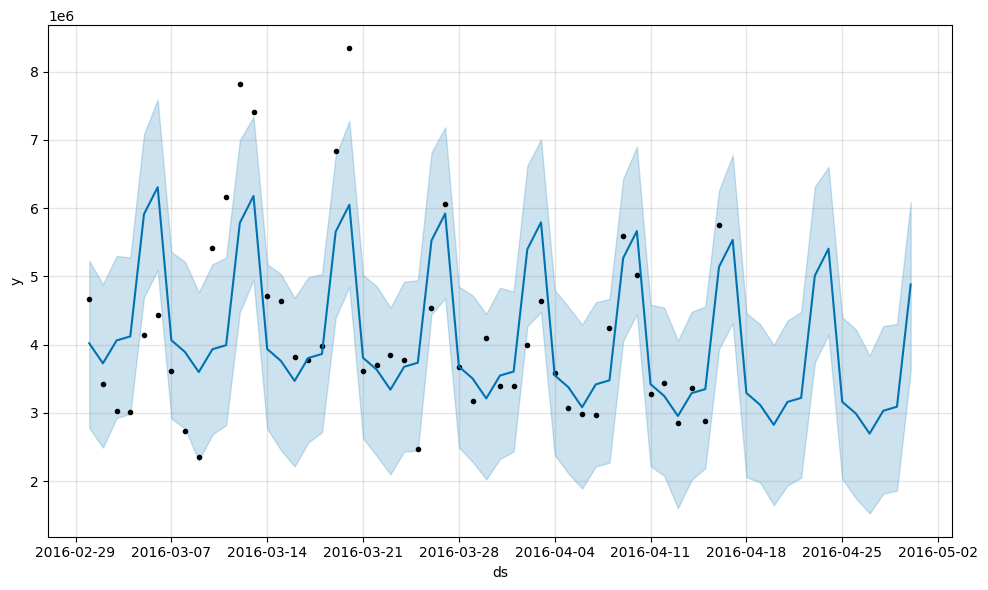

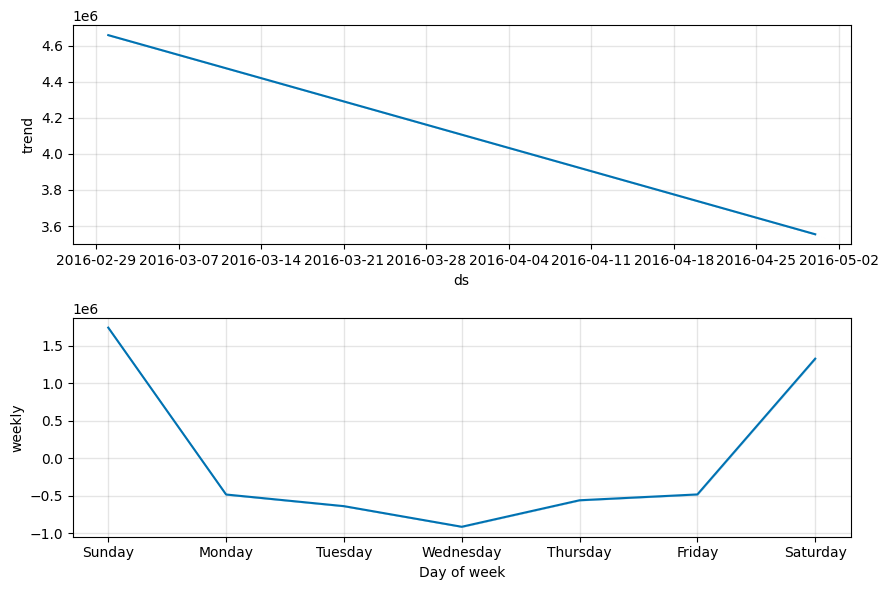

In [9]:
from sklearn.metrics import mean_absolute_percentage_error

model = Prophet()
model.fit(daily_sales[:-14])
future = model.make_future_dataframe(periods=14)
forecast = model.predict(future)
model.plot(forecast)
model.plot_components(forecast)
cmp_df = forecast.set_index('ds')[['yhat', 'yhat_lower', 'yhat_upper']].join(daily_sales.set_index('ds'))
cmp_df

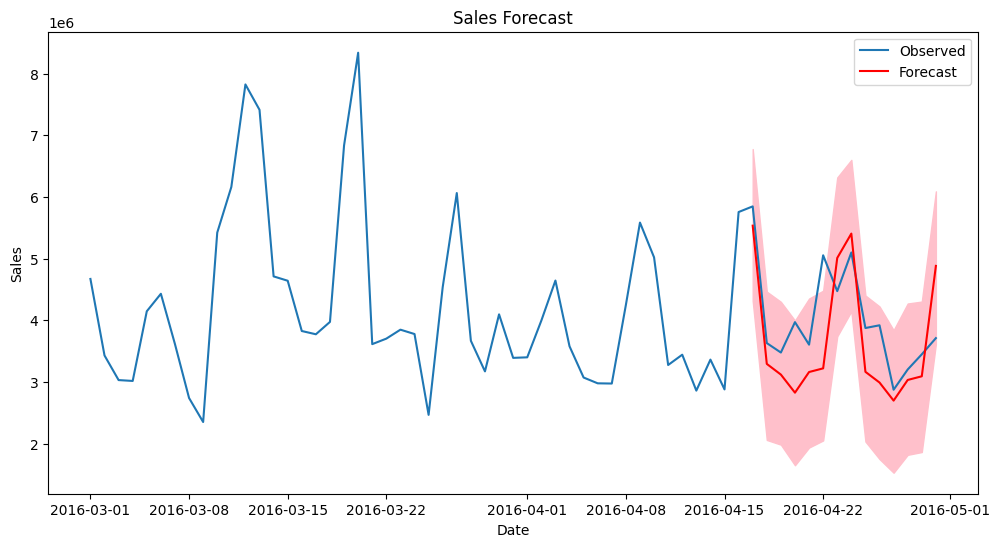

MAPE: 16.902572680948218


In [10]:
from sklearn.metrics import mean_absolute_percentage_error

# Plot the forecast
plt.figure(figsize=(12, 6))
plt.plot(cmp_df[['y']], label='Observed')
plt.plot(cmp_df[['yhat']][-14:], label='Forecast', color='red')
plt.fill_between(cmp_df[-14:].index, cmp_df['yhat_lower'][-14:], cmp_df['yhat_upper'][-14:], color='pink')
plt.title("Sales Forecast")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.show()

mape = mean_absolute_percentage_error(cmp_df['y'][:-14], cmp_df['yhat'][:-14]) * 100.0
print(f'MAPE: {mape}')